In [1]:
!pip -q install xgboost imbalanced-learn shap gradio

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("/content/UCI_Credit_Card.csv")

print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
for column in df.columns:
    print(column)

Rows: 30000
Columns: 25

Column names:
ID
LIMIT_BAL
SEX
EDUCATION
MARRIAGE
AGE
PAY_0
PAY_2
PAY_3
PAY_4
PAY_5
PAY_6
BILL_AMT1
BILL_AMT2
BILL_AMT3
BILL_AMT4
BILL_AMT5
BILL_AMT6
PAY_AMT1
PAY_AMT2
PAY_AMT3
PAY_AMT4
PAY_AMT5
PAY_AMT6
default.payment.next.month


In [4]:
missing = df.isnull().sum()

print("Total missing values:", missing.sum())

display(
    missing[missing > 0]
)

Total missing values: 0


,0


In [5]:
df = df.rename(
    columns={
        "default.payment.next.month": "default"
    }
)

print(df.columns[-1])

default


default
0    23364
1     6636
Name: count, dtype: int64

Percentage:
default
0    77.88
1    22.12
Name: proportion, dtype: float64


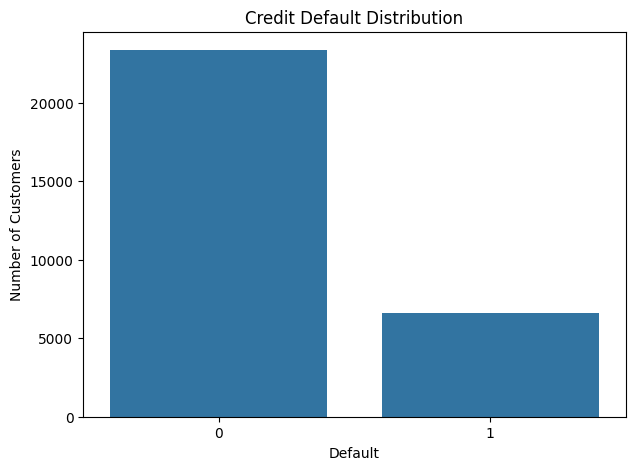

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

print(df["default"].value_counts())

print("\nPercentage:")
print(
    df["default"].value_counts(normalize=True) * 100
)

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="default"
)

plt.title("Credit Default Distribution")
plt.xlabel("Default")
plt.ylabel("Number of Customers")

plt.show()

In [7]:
df = df.drop(
    columns=["ID"]
)

print(df.shape)

(30000, 24)


In [8]:
X = df.drop(
    columns=["default"]
)

y = df["default"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30000, 23)
y shape: (30000,)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (24000, 23)
Testing data: (6000, 23)


In [10]:
from imblearn.over_sampling import SMOTE

print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
default
0    18691
1     5309
Name: count, dtype: int64

After SMOTE:
default
0    18691
1    18691
Name: count, dtype: int64


In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train_smote
)

X_test_scaled = scaler.transform(
    X_test
)

print("Scaling completed.")

Scaling completed.


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [13]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(
    X_train_scaled,
    y_train_smote
)

lr_probability = lr.predict_proba(
    X_test_scaled
)[:, 1]

print("Logistic Regression trained.")

Logistic Regression trained.


In [14]:
svm = LinearSVC(
    C=1.0,
    random_state=42,
    max_iter=5000
)

svm.fit(
    X_train_scaled,
    y_train_smote
)

svm_score = svm.decision_function(
    X_test_scaled
)

print("SVM trained.")

SVM trained.


In [15]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train_smote,
    y_train_smote
)

rf_probability = rf.predict_proba(
    X_test
)[:, 1]

print("Random Forest trained.")

Random Forest trained.


In [17]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(
    X_train_smote,
    y_train_smote
)

xgb_probability = xgb.predict_proba(
    X_test
)[:, 1]

print("XGBoost trained.")

XGBoost trained.


In [18]:
from sklearn.metrics import roc_auc_score

lr_auc = roc_auc_score(
    y_test,
    lr_probability
)

svm_auc = roc_auc_score(
    y_test,
    svm_score
)

rf_auc = roc_auc_score(
    y_test,
    rf_probability
)

xgb_auc = roc_auc_score(
    y_test,
    xgb_probability
)

results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "SVM",
        "Random Forest",
        "XGBoost"
    ],
    "ROC-AUC": [
        lr_auc,
        svm_auc,
        rf_auc,
        xgb_auc
    ]
})

results = results.sort_values(
    "ROC-AUC",
    ascending=False
)

display(results)

,Model,ROC-AUC
3,XGBoost,0.748177
2,Random Forest,0.746071
0,Logistic Regression,0.691529
1,SVM,0.689693


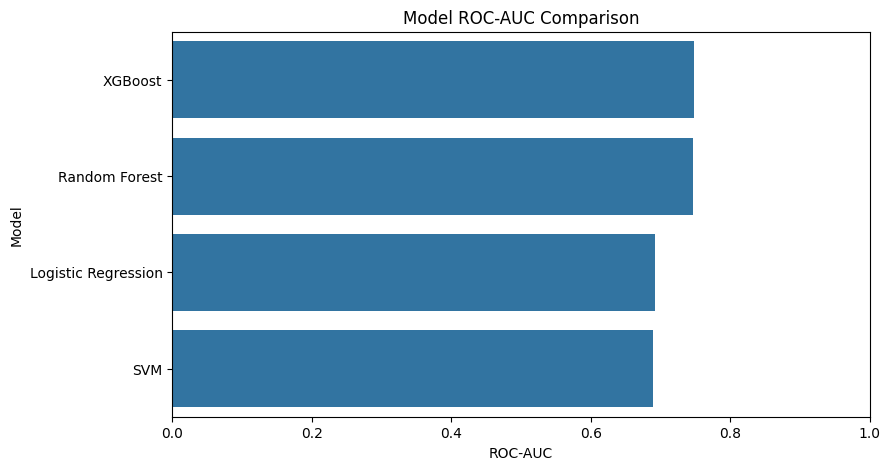

In [19]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=results,
    x="ROC-AUC",
    y="Model"
)

plt.title("Model ROC-AUC Comparison")
plt.xlim(0, 1)

plt.show()

In [20]:
best_model_name = results.iloc[0]["Model"]
best_auc = results.iloc[0]["ROC-AUC"]

print("Best Model:", best_model_name)
print("ROC-AUC:", round(best_auc, 4))

Best Model: XGBoost
ROC-AUC: 0.7482


In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

xgb_prediction = xgb.predict(
    X_test
)

print(
    classification_report(
        y_test,
        xgb_prediction
    )
)

              precision    recall  f1-score   support

           0       0.86      0.84      0.85      4673
           1       0.48      0.52      0.50      1327

    accuracy                           0.77      6000
   macro avg       0.67      0.68      0.67      6000
weighted avg       0.78      0.77      0.77      6000



In [22]:
accuracy = accuracy_score(
    y_test,
    xgb_prediction
)

precision = precision_score(
    y_test,
    xgb_prediction
)

recall = recall_score(
    y_test,
    xgb_prediction
)

f1 = f1_score(
    y_test,
    xgb_prediction
)

roc_auc = roc_auc_score(
    y_test,
    xgb_probability
)

metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

display(metrics)

,Metric,Score
0,Accuracy,0.768667
1,Precision,0.478951
2,Recall,0.522984
3,F1 Score,0.500000
4,ROC-AUC,0.748177


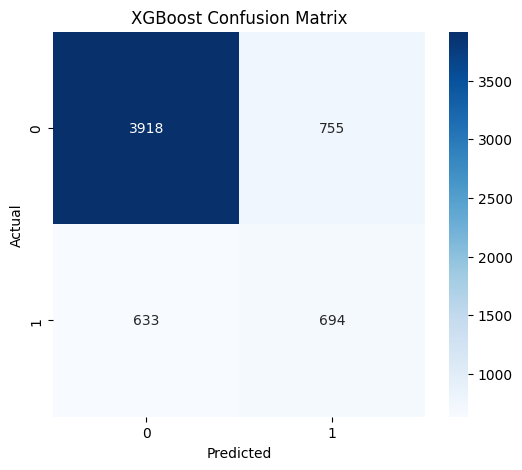

In [23]:
cm = confusion_matrix(
    y_test,
    xgb_prediction
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [24]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

display(
    importance.head(15)
)

,Feature,Importance
5,PAY_0,0.140630
1,SEX,0.122549
6,PAY_2,0.121659
7,PAY_3,0.089612
3,MARRIAGE,0.084237
9,PAY_5,0.058604
8,PAY_4,0.047778
2,EDUCATION,0.042723
10,PAY_6,0.037093
17,PAY_AMT1,0.029706


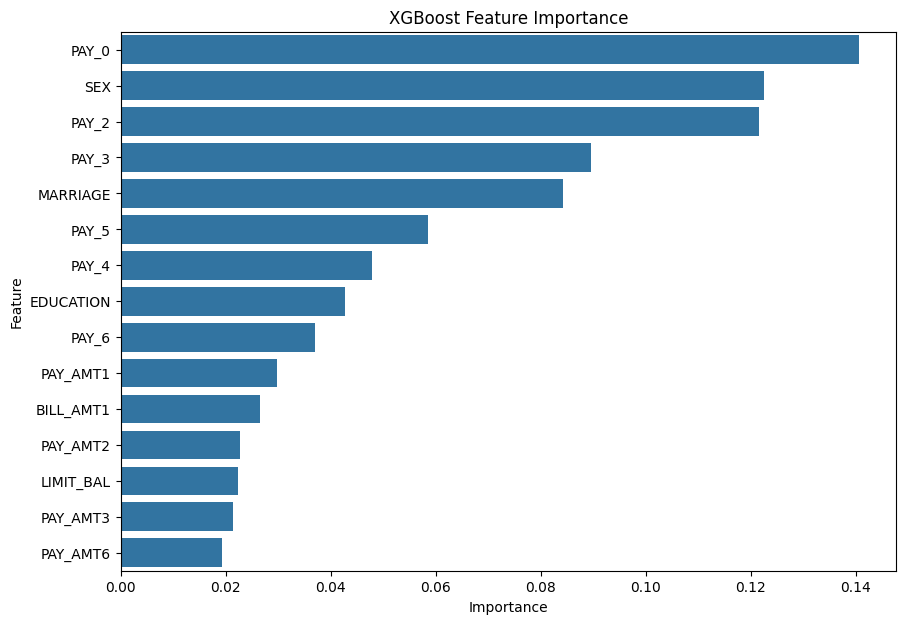

In [25]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)

plt.title("XGBoost Feature Importance")

plt.show()

In [26]:
import shap

explainer = shap.TreeExplainer(
    xgb
)

print("SHAP explainer created.")

SHAP explainer created.


In [27]:
shap_values = explainer.shap_values(
    X_test
)

print(
    "SHAP values shape:",
    shap_values.shape
)

SHAP values shape: (6000, 23)


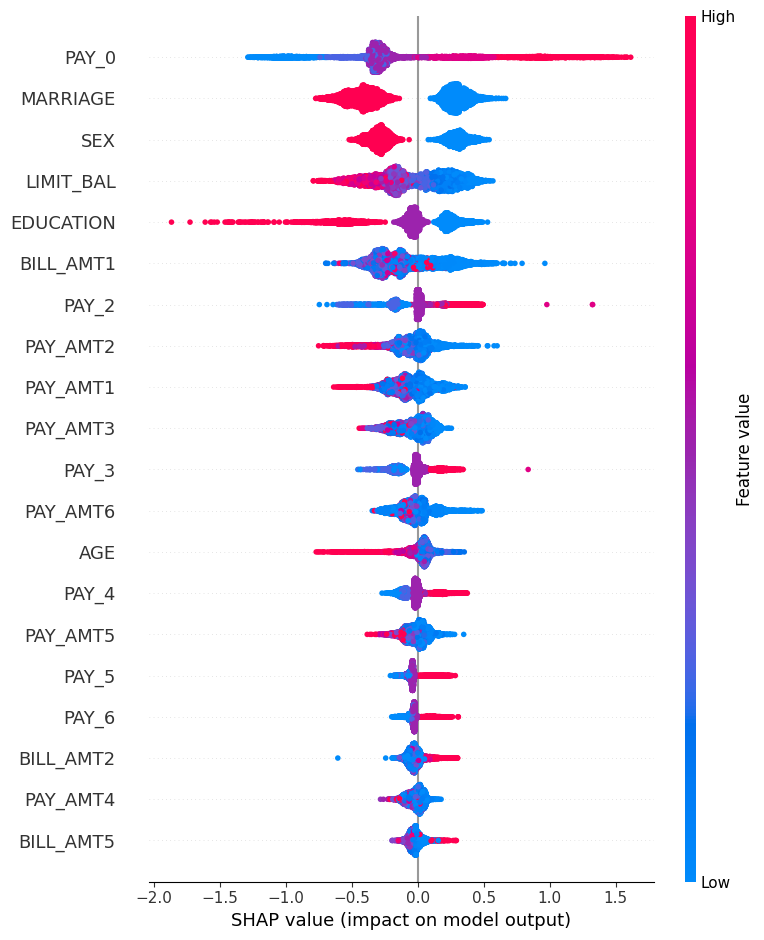

In [28]:
shap.summary_plot(
    shap_values,
    X_test
)

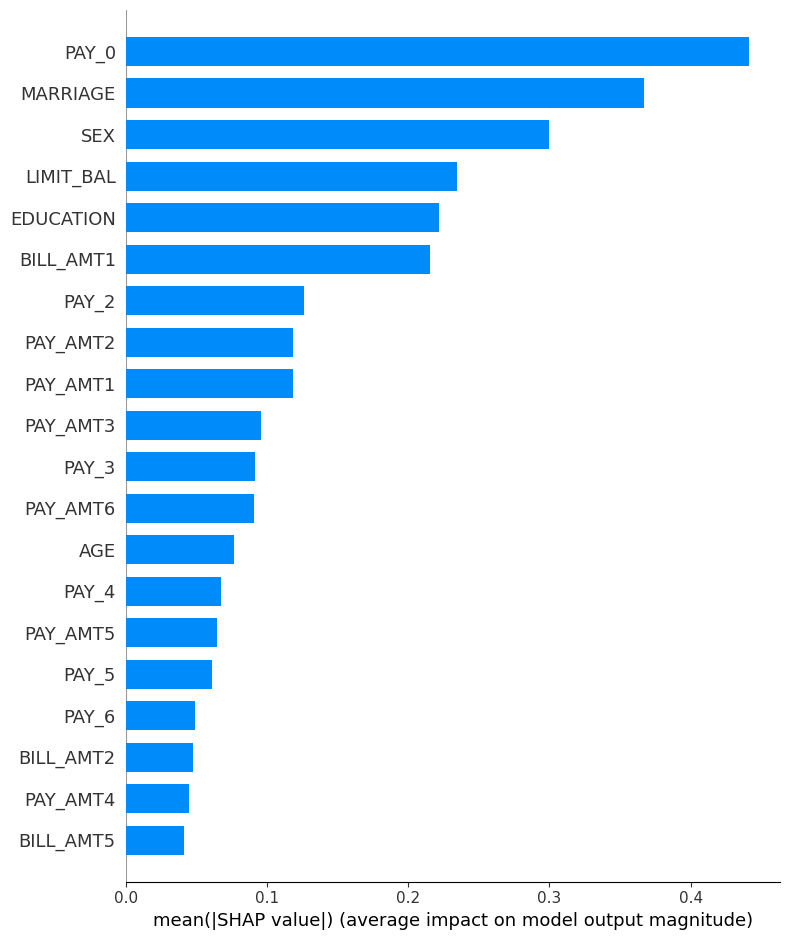

In [29]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

In [30]:
customer_index = 0

customer = X_test.iloc[
    [customer_index]
]

actual = y_test.iloc[
    customer_index
]

prediction = xgb.predict(
    customer
)[0]

probability = xgb.predict_proba(
    customer
)[0][1]

print("Actual:", actual)
print("Prediction:", prediction)
print(
    "Default probability:",
    round(probability * 100, 2),
    "%"
)

Actual: 0
Prediction: 0
Default probability: 30.89 %


In [31]:
customer_shap = shap_values[
    customer_index
]

local_explanation = pd.DataFrame({
    "Feature": X_test.columns,
    "Value": customer.iloc[0].values,
    "SHAP": customer_shap
})

local_explanation["Absolute_SHAP"] = (
    local_explanation["SHAP"].abs()
)

local_explanation = local_explanation.sort_values(
    "Absolute_SHAP",
    ascending=False
)

display(
    local_explanation.head(10)
)

,Feature,Value,SHAP,Absolute_SHAP
5,PAY_0,-1.0,-0.385771,0.385771
3,MARRIAGE,2.0,-0.354747,0.354747
1,SEX,1.0,0.221058,0.221058
0,LIMIT_BAL,50000.0,0.172981,0.172981
6,PAY_2,-1.0,-0.170711,0.170711
11,BILL_AMT1,1540.0,0.158119,0.158119
7,PAY_3,-1.0,-0.153882,0.153882
8,PAY_4,-1.0,-0.133114,0.133114
21,PAY_AMT5,1764.0,0.130343,0.130343
17,PAY_AMT1,26060.0,-0.128793,0.128793


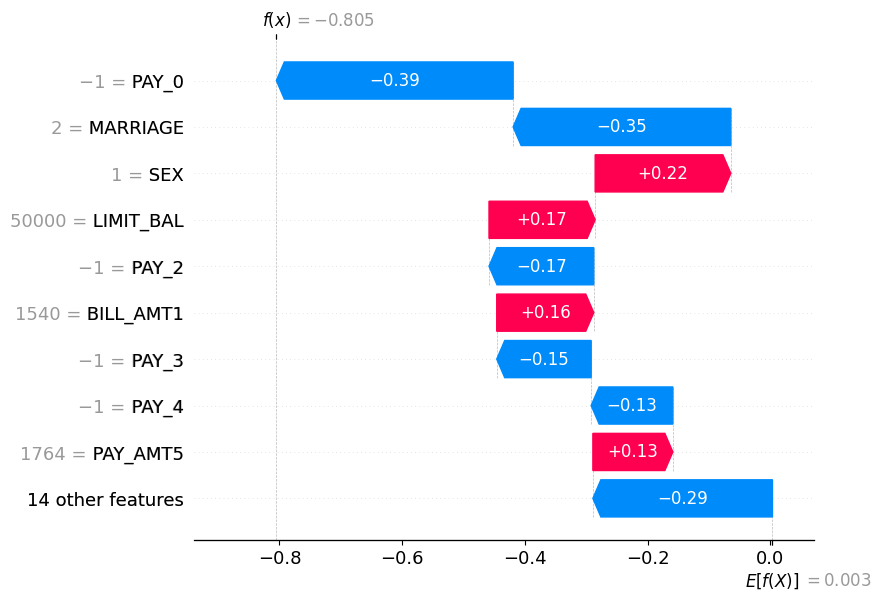

In [32]:
shap.waterfall_plot(
    shap.Explanation(
        values=customer_shap,
        base_values=explainer.expected_value,
        data=customer.iloc[0].values,
        feature_names=X_test.columns
    )
)

In [33]:
original_customer = customer.copy()

original_probability = xgb.predict_proba(
    original_customer
)[0][1]

original_prediction = xgb.predict(
    original_customer
)[0]

print(
    "Original prediction:",
    original_prediction
)

print(
    "Original probability:",
    round(original_probability * 100, 2),
    "%"
)

Original prediction: 0
Original probability: 30.89 %


In [34]:
counterfactuals = []

payment_features = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

for feature in payment_features:

    for value in [-2, -1, 0, 1, 2]:

        modified = original_customer.copy()

        modified[feature] = value

        probability = xgb.predict_proba(
            modified
        )[0][1]

        prediction = xgb.predict(
            modified
        )[0]

        if prediction != original_prediction:

            counterfactuals.append({
                "Changed Feature": feature,
                "New Value": value,
                "New Prediction": prediction,
                "New Probability": probability
            })

counterfactual_df = pd.DataFrame(
    counterfactuals
)

display(counterfactual_df.head(10))

,Changed Feature,New Value,New Prediction,New Probability
0,PAY_0,0,1,0.504595
1,PAY_2,1,1,0.578483
2,PAY_3,1,1,0.702090
3,PAY_4,1,1,0.692596
4,PAY_5,1,1,0.557759
5,PAY_6,1,1,0.548106


In [35]:
if len(counterfactual_df) > 0:

    row = counterfactual_df.iloc[0]

    print("Counterfactual explanation")
    print("---------------------------")

    print(
        f"Change {row['Changed Feature']} "
        f"to {row['New Value']}."
    )

    print(
        f"New predicted probability: "
        f"{row['New Probability'] * 100:.2f}%"
    )

else:

    print(
        "No simple counterfactual was found "
        "using the tested repayment-history values."
    )

Counterfactual explanation
---------------------------
Change PAY_0 to 0.
New predicted probability: 50.46%


In [36]:
def predict_customer(customer_data):

    prediction = xgb.predict(
        customer_data
    )[0]

    probability = xgb.predict_proba(
        customer_data
    )[0][1]

    shap_result = explainer.shap_values(
        customer_data
    )[0]

    explanation = pd.DataFrame({
        "Feature": X.columns,
        "Value": customer_data.iloc[0].values,
        "SHAP": shap_result
    })

    explanation["Importance"] = (
        explanation["SHAP"].abs()
    )

    explanation = explanation.sort_values(
        "Importance",
        ascending=False
    )

    return (
        prediction,
        probability,
        explanation.head(5)
    )

In [37]:
prediction, probability, explanation = (
    predict_customer(customer)
)

print(
    "Prediction:",
    "Default" if prediction == 1 else "No Default"
)

print(
    "Probability:",
    round(probability * 100, 2),
    "%"
)

display(explanation)

Prediction: No Default
Probability: 30.89 %


,Feature,Value,SHAP,Importance
5,PAY_0,-1.0,-0.385771,0.385771
3,MARRIAGE,2.0,-0.354747,0.354747
1,SEX,1.0,0.221058,0.221058
0,LIMIT_BAL,50000.0,0.172981,0.172981
6,PAY_2,-1.0,-0.170711,0.170711


In [38]:
import gradio as gr

In [39]:
def app_prediction(
    LIMIT_BAL,
    SEX,
    EDUCATION,
    MARRIAGE,
    AGE,
    PAY_0,
    PAY_2,
    PAY_3,
    PAY_4,
    PAY_5,
    PAY_6,
    BILL_AMT1,
    BILL_AMT2,
    BILL_AMT3,
    BILL_AMT4,
    BILL_AMT5,
    BILL_AMT6,
    PAY_AMT1,
    PAY_AMT2,
    PAY_AMT3,
    PAY_AMT4,
    PAY_AMT5,
    PAY_AMT6
):

    values = [[
        LIMIT_BAL,
        SEX,
        EDUCATION,
        MARRIAGE,
        AGE,
        PAY_0,
        PAY_2,
        PAY_3,
        PAY_4,
        PAY_5,
        PAY_6,
        BILL_AMT1,
        BILL_AMT2,
        BILL_AMT3,
        BILL_AMT4,
        BILL_AMT5,
        BILL_AMT6,
        PAY_AMT1,
        PAY_AMT2,
        PAY_AMT3,
        PAY_AMT4,
        PAY_AMT5,
        PAY_AMT6
    ]]

    customer = pd.DataFrame(
        values,
        columns=X.columns
    )

    prediction = xgb.predict(
        customer
    )[0]

    probability = xgb.predict_proba(
        customer
    )[0][1]

    shap_result = explainer.shap_values(
        customer
    )[0]

    explanation = pd.DataFrame({
        "Feature": X.columns,
        "Value": customer.iloc[0].values,
        "SHAP Contribution": shap_result
    })

    explanation["Importance"] = (
        explanation["SHAP Contribution"].abs()
    )

    explanation = explanation.sort_values(
        "Importance",
        ascending=False
    )

    top = explanation.head(5)

    if prediction == 1:

        result = "⚠️ Higher Risk of Default"

    else:

        result = "✅ Lower Risk of Default"

    explanation_text = ""

    for _, row in top.iterrows():

        direction = (
            "increases risk"
            if row["SHAP Contribution"] > 0
            else "decreases risk"
        )

        explanation_text += (
            f"• {row['Feature']}: "
            f"{direction} "
            f"(SHAP = {row['SHAP Contribution']:.3f})\n"
        )

    return (
        result,
        f"{probability * 100:.2f}%",
        explanation_text
    )

In [41]:
demo = gr.Interface(
    fn=app_prediction,

    inputs=[
        gr.Number(label="Credit Limit", value=50000),
        gr.Number(label="Sex", value=2),
        gr.Number(label="Education", value=2),
        gr.Number(label="Marriage", value=1),
        gr.Number(label="Age", value=30),

        gr.Number(label="PAY_0", value=0),
        gr.Number(label="PAY_2", value=0),
        gr.Number(label="PAY_3", value=0),
        gr.Number(label="PAY_4", value=0),
        gr.Number(label="PAY_5", value=0),
        gr.Number(label="PAY_6", value=0),

        gr.Number(label="BILL_AMT1", value=5000),
        gr.Number(label="BILL_AMT2", value=5000),
        gr.Number(label="BILL_AMT3", value=5000),
        gr.Number(label="BILL_AMT4", value=5000),
        gr.Number(label="BILL_AMT5", value=5000),
        gr.Number(label="BILL_AMT6", value=5000),

        gr.Number(label="PAY_AMT1", value=1000),
        gr.Number(label="PAY_AMT2", value=1000),
        gr.Number(label="PAY_AMT3", value=1000),
        gr.Number(label="PAY_AMT4", value=1000),
        gr.Number(label="PAY_AMT5", value=1000),
        gr.Number(label="PAY_AMT6", value=1000)
    ],

    outputs=[
        gr.Textbox(label="Prediction"),
        gr.Textbox(label="Default Probability"),
        gr.Textbox(label="Top XAI Factors")
    ],

    title="Explainable Credit Default Prediction",

    description=(
        "Enter customer information to predict "
        "credit default risk and understand "
        "the main factors influencing the prediction."
    )
)

In [42]:
demo.launch(
    share=True
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b79672e05391b1a39e.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [43]:
import joblib

joblib.dump(
    xgb,
    "xgboost_credit_default_model.pkl"
)

print("Model saved.")

Model saved.


In [44]:
from google.colab import files

files.download(
    "xgboost_credit_default_model.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [45]:
results.to_csv(
    "model_comparison.csv",
    index=False
)

metrics.to_csv(
    "xgboost_metrics.csv",
    index=False
)

print("Results saved.")

Results saved.


In [46]:
files.download("model_comparison.csv")
files.download("xgboost_metrics.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>